# Y-axis orientation — north-up reads, whatever the file stores

NetCDF producers write their rows in whichever order they like: most store latitude **south→north** (row 0 at the
south edge), some store it north→south, and satellite products store packed scan angles whose direction isn't even
visible in the raw numbers. Rasters follow one convention: **row 0 is the north edge**.

`pyramids` reconciles the two on read. Whatever the storage order, `read_array()`, `plot()`, and the `lat` / `y`
coordinate accessors always come back **north-up** — you never have to know how the file was written. This notebook
shows that guarantee holding across the three storage layouts you'll actually meet, and what would go wrong without
it ([#705](https://github.com/serapeum-org/pyramids/issues/705) was exactly that failure):

| file | latitude / y stored | what `pyramids` does |
|---|---|---|
| NOAH precipitation (global) | south → north | reverses the rows |
| NCEP `air` temperature | north → south | leaves them alone |
| GOES-16 satellite imagery | packed scan angle, direction hidden by a negative `scale_factor` | reads the *physical* direction, leaves them alone |

In [1]:
%matplotlib inline
from pathlib import Path

import numpy as np

from pyramids.netcdf import NetCDF

DATA = Path('../../../../examples/data/netcdf/samples')

2026-07-11 01:37:22 | INFO | pyramids.base.config | Logging is configured.


## Case 1 — latitude stored south → north (the common case)

This NOAH precipitation file is a real global 0.5° grid whose latitude runs −89.75° → 89.75° in storage: row 0 of
the file is the *south* edge. After opening, everything is already north-up — the first latitude is the northernmost,
and the geotransform's pixel height is negative (the raster-convention way of saying "rows go downward from the
north edge").

In [2]:
noah = NetCDF.read_file(DATA / 'cf__6v__1d2-2d4__geog__y-asc.nc').get_variable('Band1')
print(f'first latitude : {noah.lat[0]:7.2f}   (northernmost)')
print(f'last  latitude : {noah.lat[-1]:7.2f}   (southernmost)')
print(f'pixel height   : {noah.geotransform[5]:7.2f}   (negative = north-up)')

first latitude :   89.75   (northernmost)
last  latitude :  -89.75   (southernmost)
pixel height   :   -0.50   (negative = north-up)


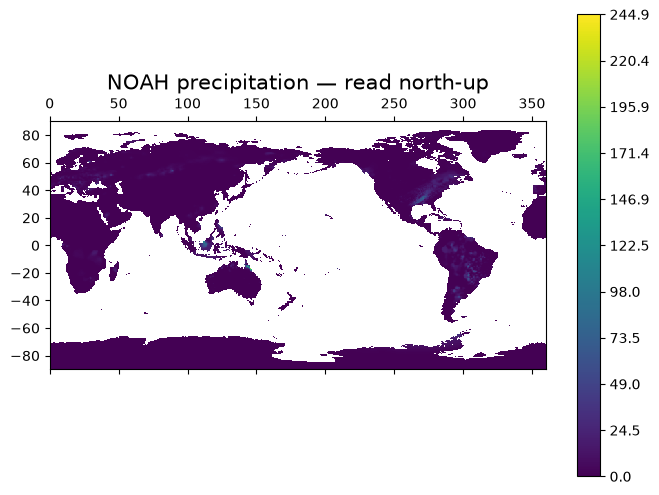

In [3]:
glyph = noah.plot(title='NOAH precipitation — read north-up', cmap='viridis')

The world is the right way up. To see what the guarantee is protecting you from, flip the same array upside
down and give it the same georeferencing — this simulates a reader that trusted the file's storage order:

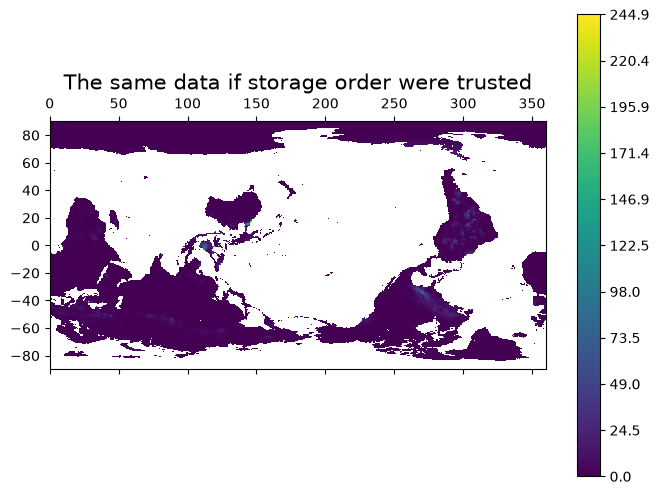

In [4]:
mirrored = np.flipud(noah.read_array()).astype('float64')
mirrored[mirrored == noah.no_data_value[0]] = np.nan   # keep the fill out of the colour scale
bug = NetCDF.create_from_array(
    arr=mirrored, geo=noah.geotransform, epsg=4326, variable_name='wrong'
).get_variable('wrong')
glyph = bug.plot(title='The same data if storage order were trusted', cmap='viridis')

An upside-down planet is easy to spot. The dangerous version of this bug is a regional file, where the mirrored
raster still *looks* plausible — every value you sample at a coordinate is silently wrong. That is what happened in
[#705](https://github.com/serapeum-org/pyramids/issues/705), and it's why the orientation is normalized at read time
rather than left to the caller.

## Case 2 — latitude stored north → south (nothing to undo)

Some producers already write north-first. This NCEP reanalysis air-temperature file stores latitude 75° → 15°, so
its rows already match the raster convention and `pyramids` leaves them untouched. The point of this case: the API
looks **identical**. You cannot tell from the outside whether a flip happened — that's the contract.

In [5]:
air = NetCDF.read_file(DATA / 'coards__4v__1d3-3d1__y-desc.nc').get_variable('air')
print(f'first latitude : {air.lat[0]:7.2f}   (northernmost)')
print(f'last  latitude : {air.lat[-1]:7.2f}   (southernmost)')
print(f'pixel height   : {air.geotransform[5]:7.2f}   (negative = north-up)')

first latitude :   75.00   (northernmost)
last  latitude :   15.00   (southernmost)
pixel height   :   -2.50   (negative = north-up)


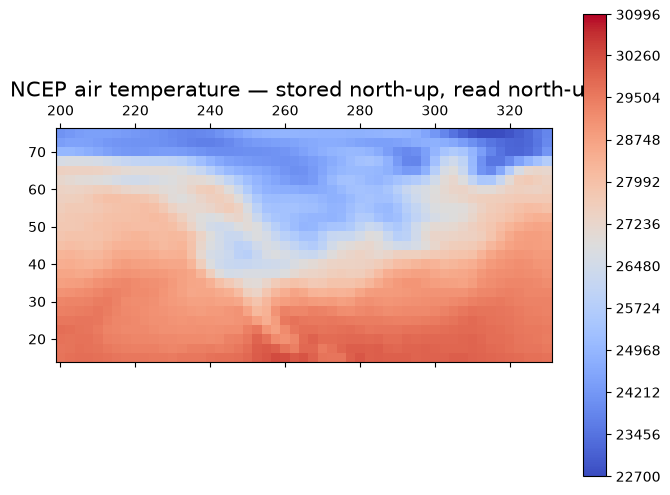

In [6]:
glyph = air.plot(title='NCEP air temperature — stored north-up, read north-up', cmap='coolwarm')

## Case 3 — the satellite trap: packed coordinates ([#705](https://github.com/serapeum-org/pyramids/issues/705))

A real GOES-16 granule (Cloud & Moisture Imagery). Its `y` coordinate is the satellite's scan angle, stored as
`int16` and unpacked through `scale_factor ≈ −5.6e-05` — **negative**. So the integers *stored in the file ascend*
while the *physical coordinate descends*: the storage order and the real direction point opposite ways, and any
reader that judges orientation from the raw storage (or from anything derived from it) flips an image that was
already north-up.

`pyramids` decides from the physical coordinate. The `y` accessor shows the result — projected metres, descending,
row 0 at the top of the scan:

In [7]:
goes = NetCDF.read_file(DATA / 'cf__9v__1d7-2d2__geos__y-desc.nc').get_variable('CMI')
print(f'first y : {goes.y[0]:>12,.0f} m   (top of the image)')
print(f'last  y : {goes.y[-1]:>12,.0f} m')
print(f'pixel   : {goes.geotransform[1]:>12,.0f} m   (a ~2 km geostationary grid)')

2026-07-11 01:37:24 | WARNING | pyramids.base.config.gdal | GDAL[1] Unhandled X/Y axis unit rad. SRS will ignore axis unit and be likely wrong.


first y :    1,502,011 m   (top of the image)
last  y :      502,006 m
pixel   :        2,004 m   (a ~2 km geostationary grid)


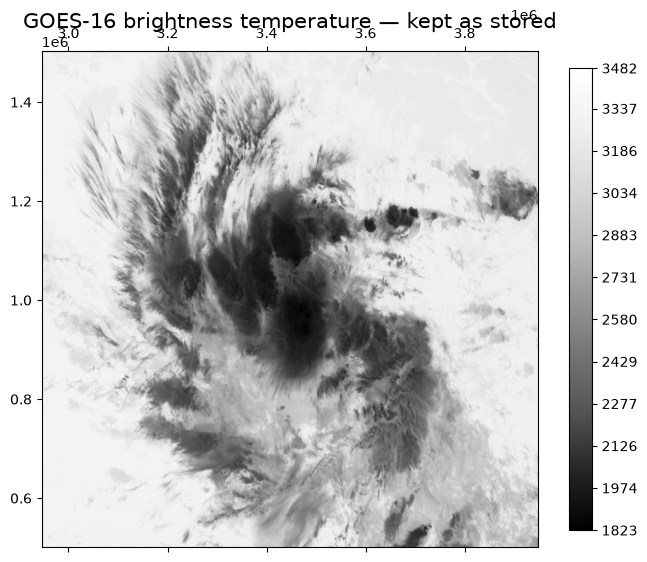

In [8]:
glyph = goes.plot(title='GOES-16 brightness temperature — kept as stored', cmap='Greys_r')

Before the fix, this exact kind of file came back **vertically mirrored** — no error, plausible-looking clouds,
wrong values at every coordinate. The reporter of #705 found it by sampling known locations after reprojecting, so
finish the same way: reproject to geographic coordinates. This mesoscale sector is tracking a tropical system over
the open Atlantic (5–14°N); with the old, mirrored read every cloud band landed at the wrong latitude, so any value
sampled at real storm coordinates was silently wrong.

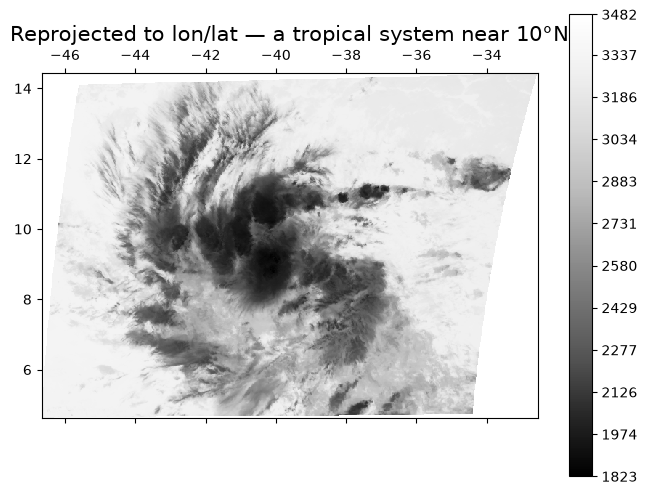

In [9]:
geographic = goes.to_crs(4326)
glyph = geographic.plot(title='Reprojected to lon/lat — a tropical system near 10°N', cmap='Greys_r')

## One guarantee, every read path

The same normalization applies no matter how you read: the eager `read_array()` and the chunked (dask-backed)
`read_array(chunks=...)` return identical, north-up arrays. It also covers layouts not shown here — projected grids
stored bottom-up and even a longitude stored east→west (column 0 always ends up at the *west* edge).

In [10]:
for name, variable in [('cf__6v__1d2-2d4__geog__y-asc.nc', 'Band1'),
                       ('coards__4v__1d3-3d1__y-desc.nc', 'air'),
                       ('cf__9v__1d7-2d2__geos__y-desc.nc', 'CMI')]:
    var = NetCDF.read_file(DATA / name).get_variable(variable)
    same = np.array_equal(np.asarray(var.read_array(chunks='auto')), var.read_array())
    print(f'{name:38s} {variable:6s} chunked == eager: {same}')

2026-07-11 01:37:26 | WARNING | pyramids.base.config.gdal | GDAL[1] Unhandled X/Y axis unit rad. SRS will ignore axis unit and be likely wrong.


cf__6v__1d2-2d4__geog__y-asc.nc        Band1  chunked == eager: True
coards__4v__1d3-3d1__y-desc.nc         air    chunked == eager: True
cf__9v__1d7-2d2__geos__y-desc.nc       CMI    chunked == eager: True


## Takeaway

- Files store rows in any order; rasters are **row 0 = north**. `pyramids` converts on read, every time.
- `read_array()`, `plot()`, `lat` / `y`, and the geotransform are always north-up — across geographic, projected,
  and geostationary files, and across the eager and chunked read paths alike.
- The one storage layout that fools order-based readers is a coordinate packed with a **negative** `scale_factor`
  (the GOES case): the stored numbers run opposite to the physical axis. Deciding from the physical coordinate is
  what closed [#705](https://github.com/serapeum-org/pyramids/issues/705).